# **Data Visualisation**

## Objectives

* Load the cleaned dataset used in the EDA notebook
* Create polished presentation ready visualisations for each hypothesis tested in the EDA notebook
* Build a correlation matrix summarising how the numeric features relate to each other

## Inputs

* Cleaned dataset: Dataset/CleanData/healthcare_cleaned_deidentified.csv



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Healthcare_Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Healthcare_Analysis'

### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Clean Dataset

In [8]:
df = pd.read_csv('Dataset/CleanData/healthcare_cleaned_deidentified.csv')
print('The Dataset has been loadedd!')
df.head()

The Dataset has been loadedd!


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal,2
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal,15
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,20


---

### Set colours for graphs

In [9]:
sns.set_style('whitegrid')

primary_color = '#C8102E'   # red - represents hospitals/healthcare
secondary_color = '#F5F0E6'  # cream - represents hospitals/healthcare

# H1: Billing Amount and Medical Condition - Visualisations

A box plot comparing Billing Amount across Medical Condition. This helps visually confirm the result found in the EDA ANOVA test by showing the spread and median of billing amount for each condition side by side.

/var/folders/l0/lvgdkkwj72sd1m4qyfcktzq80000gn/T/ipykernel_9458/4004252929.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#C8102E'` for the same effect.

  sns.boxplot(x='Medical Condition', y='Billing Amount', data=df,


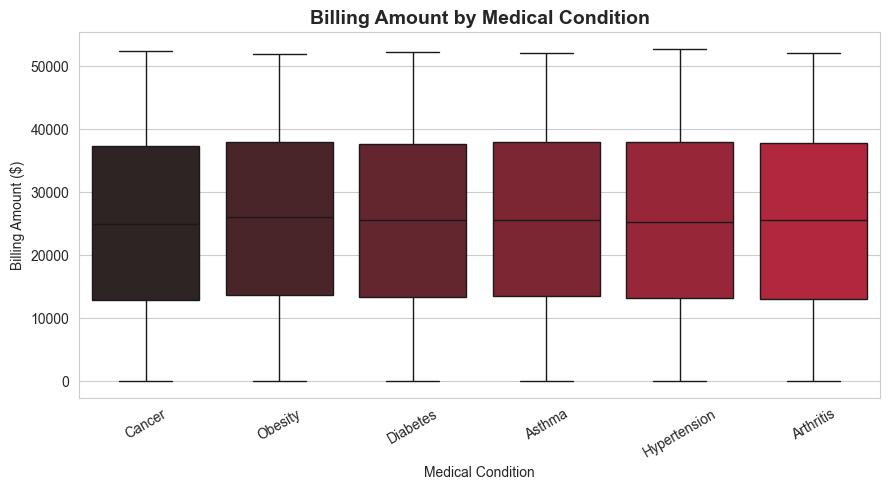

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(x='Medical Condition', y='Billing Amount', data=df,
            hue='Medical Condition', color=primary_color, legend=False, ax=ax)
ax.set_title('Billing Amount by Medical Condition', fontsize=14, fontweight='bold')
ax.set_xlabel('Medical Condition')
ax.set_ylabel('Billing Amount ($)')
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

The box plot shows the billing amount distributions overlap heavily across all six conditions with no condition standing out as noticeably more expensive than the others. This matches the EDA result. The ANOVA test was only just significant (p = 0.049) and the actual difference between condition means was small compared to how spread out billing amount is within each condition.

A supporting bar chart showing the mean billing amount for each medical condition to make the small differences between conditions easier to see than they are on the box plot.

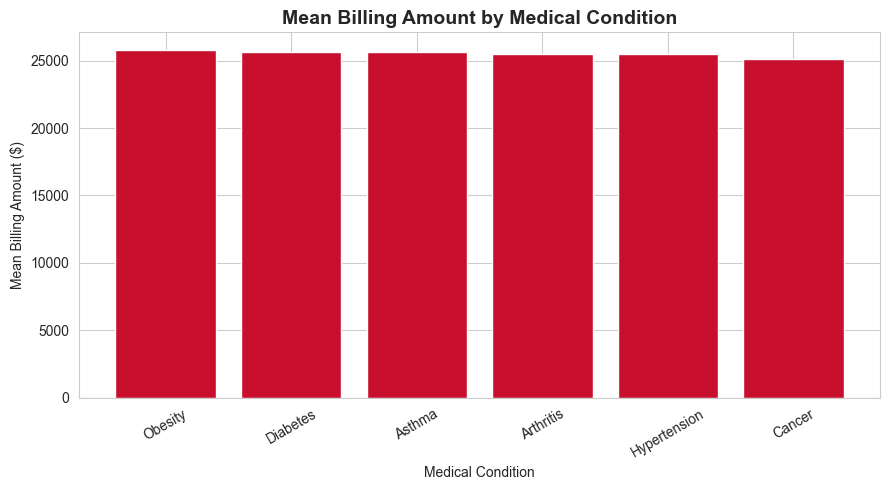

In [12]:
mean_billing = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(mean_billing.index, mean_billing.values, color=primary_color)
ax.set_title('Mean Billing Amount by Medical Condition', fontsize=14, fontweight='bold')
ax.set_xlabel('Medical Condition')
ax.set_ylabel('Mean Billing Amount ($)')
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

This chart makes the small gap between conditions easier to see than the box plot, Obesity has the highest mean billing at around $25,807, while Cancer has the lowest at around $25,155. Even zoomed in like this, the difference between the highest and lowest condition is only about $650, which is a small gap in absolute terms. This supports the same conclusion as the ANOVA test, statistically detectable but not practically meaningful.

Both charts support the same reading of H1: the box plot shows heavy overlap between conditions while the bar chart confirms the actual difference between the highest and lowest mean is small, backing up the EDA conclusion that this result while technically significant isn't a pattern worth acting on.

# H2: Test Results and Insurance Provider - Visualisation

A stacked bar chart showing the percentage split of Test Results within each Insurance Provider. This helps visually confirm the result found in the EDA chi-square test by showing whether any insurer has a noticeably different mix of outcomes.

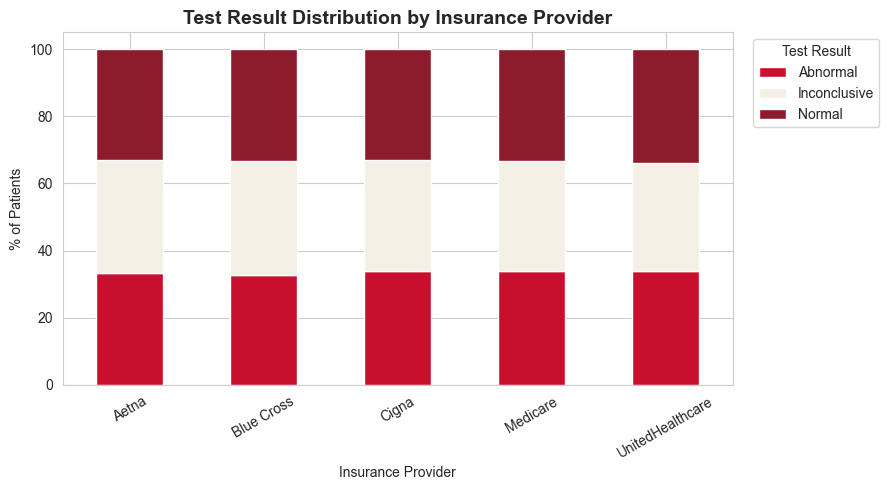

In [14]:
ct = pd.crosstab(df['Insurance Provider'], df['Test Results'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(9, 5))
ct.plot(kind='bar', stacked=True, ax=ax, color=[primary_color, secondary_color, '#8C1C2B'])
ax.set_title('Test Result Distribution by Insurance Provider', fontsize=14, fontweight='bold')
ax.set_xlabel('Insurance Provider')
ax.set_ylabel('% of Patients')
plt.xticks(rotation=30)
ax.legend(title='Test Result', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()

The stacked bar chart shows each insurer's split between Normal, Abnormal, and Inconclusive results is almost identical roughly 32-34% each. No insurer stands out with a noticeably different outcome mix. This matches the EDA result the chi-square test found no significant association (p = 0.339) between insurance provider and test results.

# H3: Age and Admission Type - Visualisation

A box plot comparing Age across Admission Type. This helps visually confirm the result found in the EDA ANOVA test by showing the spread and median of age for each admission type side by side.

/var/folders/l0/lvgdkkwj72sd1m4qyfcktzq80000gn/T/ipykernel_9458/632100082.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#C8102E'` for the same effect.

  sns.boxplot(x='Admission Type', y='Age', data=df,


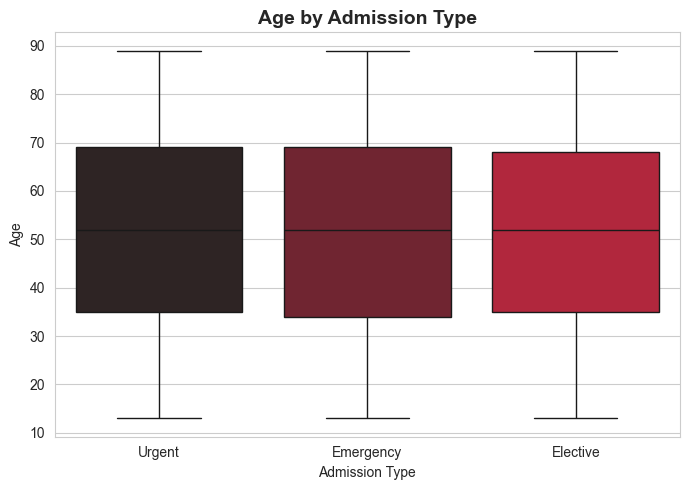

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x='Admission Type', y='Age', data=df,
            hue='Admission Type', color=primary_color, legend=False, ax=ax)
ax.set_title('Age by Admission Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Admission Type')
ax.set_ylabel('Age')
plt.tight_layout()

plt.show()

The box plot shows the age distributions overlap almost completely across all three admission types with no admission type standing out as noticeably older or younger than the others. This matches the EDA result the ANOVA test found no significant difference (p = 0.630) in age across admission types.

# H4: Billing Amount and Gender - Visualisation

A box plot comparing Billing Amount between Male and Female patients. This helps visually confirm the result found in the EDA t-test by showing the spread and median of billing amount for each gender side by side.

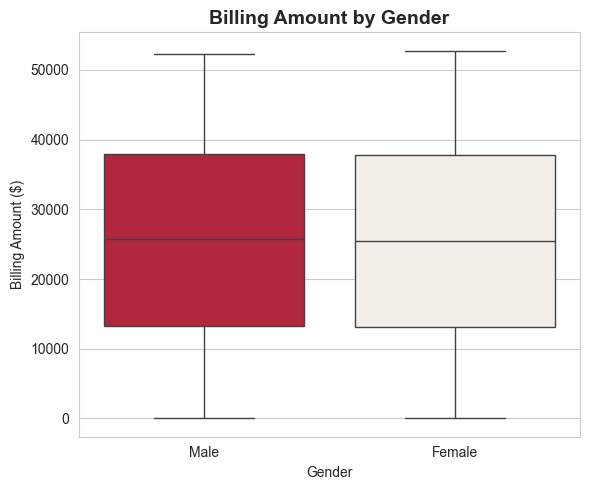

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x='Gender', y='Billing Amount', data=df,
            hue='Gender', palette=[primary_color, secondary_color], legend=False, ax=ax)
ax.set_title('Billing Amount by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Billing Amount ($)')
plt.tight_layout()

plt.show()

The box plot shows the billing amount distributions overlap almost completely between Male and Female patients with no visible difference between the two. This matches the EDA result the t-test found no significant difference (p = 0.247) in billing amount between genders.

# H5: Medical Condition and Admission Type - Visualisation

A heatmap showing the count of patients for each combination of Medical Condition and Admission Type. This helps visually confirm the result found in the EDA chi-square test by showing whether any combination stands out with an unusually high or low count.

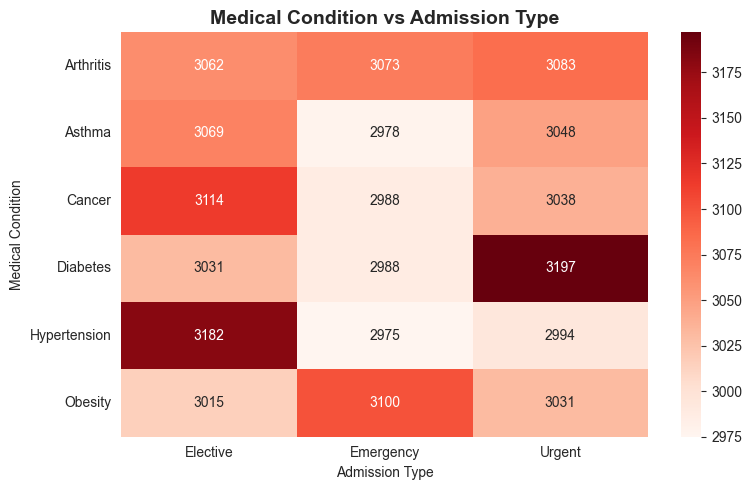

In [17]:
ct5 = pd.crosstab(df['Medical Condition'], df['Admission Type'])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct5, annot=True, fmt='d', cmap='Reds', ax=ax)
ax.set_title('Medical Condition vs Admission Type', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

The heatmap shows counts are spread fairly evenly across the grid with no condition/admission type combination standing out as unusually high or low. This matches the EDA result the chi-square test found no significant association (p = 0.057 borderline) between medical condition and admission type.

# Correlation Matrix

This heatmap will show how the numeric features relate to each other. There are only three genuinely numeric variables in this dataset, Age, Billing Amount and Length of Stay, since Room Number was dropped in ETL as a non-analytical identifier.

In [18]:
numeric_df = df[['Age', 'Billing Amount', 'Length of Stay']]
correlation = numeric_df.corr()
correlation

,Age,Billing Amount,Length of Stay
Age,1.00000,-0.003410,0.007890
Billing Amount,-0.00341,1.000000,-0.004869
Length of Stay,0.00789,-0.004869,1.000000


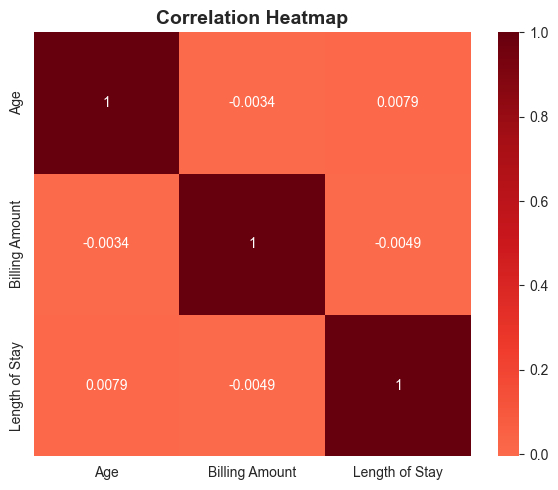

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Reds', center=0, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

The heatmap shows no meaningful correlation between any pair of numeric variables, all values sit close to 0. This is consistent with every hypothesis test result found in the EDA notebook this dataset doesn't show much real relationship between these variables.

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [6]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)